In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
DATA_DIR = "/content/drive/MyDrive/FYP Project Data/images"
CSV_PATH = "/content/drive/MyDrive/FYP Project Data/fitzpatrick17k.csv"

In [3]:
!pip install aif360

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.7/259.7 kB 22.1 MB/s eta 0:00:00


In [4]:
import os, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models, transforms

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, balanced_accuracy_score
from sklearn.linear_model import LogisticRegression

from imblearn.over_sampling import SMOTE, BorderlineSMOTE, ADASYN, KMeansSMOTE

import tensorflow.compat.v1 as tf
tf.disable_eager_execution()

from aif360.datasets import BinaryLabelDataset
from aif360.algorithms.preprocessing import Reweighing
from aif360.algorithms.inprocessing import AdversarialDebiasing
from aif360.algorithms.postprocessing import CalibratedEqOddsPostprocessing

warnings.filterwarnings("ignore")

# ── Reproducibility ────────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

# ── Hardware ───────────────────────────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# ── Hyperparams ────────────────────────────────────────────────────────────────
IMG_SIZE    = 224
BATCH_SIZE  = 32
EPOCHS      = 10      # increase to 20 for better accuracy
LR          = 1e-4
NUM_WORKERS = 2

# ── AIF360 group definitions ───────────────────────────────────────────────────
# Fitzpatrick 1-3 = light skin = privileged
# Fitzpatrick 4-6 = dark  skin = unprivileged
PRIV   = [{"skin_tone": 1}]
UNPRIV = [{"skin_tone": 0}]


pip install 'aif360[Reductions]'
pip install 'aif360[Reductions]'
pip install 'aif360[inFairness]'
pip install 'aif360[Reductions]'


Using device: cuda


In [5]:
df_raw = pd.read_csv(CSV_PATH)
print("Shape:", df_raw.shape)
print("\nColumns:", list(df_raw.columns))
df_raw.head(3)


Shape: (16577, 9)

Columns: ['md5hash', 'fitzpatrick_scale', 'fitzpatrick_centaur', 'label', 'nine_partition_label', 'three_partition_label', 'qc', 'url', 'url_alphanum']


,md5hash,fitzpatrick_scale,fitzpatrick_centaur,label,nine_partition_label,three_partition_label,qc,url,url_alphanum
0,5e82a45bc5d78bd24ae9202d194423f8,3,3,drug induced pigmentary changes,inflammatory,non-neoplastic,NaN,https://www.dermaamin.com/site/images/clinical...,httpwwwdermaamincomsiteimagesclinicalpicmminoc...
1,fa2911a9b13b6f8af79cb700937cc14f,1,1,photodermatoses,inflammatory,non-neoplastic,NaN,https://www.dermaamin.com/site/images/clinical...,httpwwwdermaamincomsiteimagesclinicalpicpphoto...
2,d2bac3c9e4499032ca8e9b07c7d3bc40,2,3,dermatofibroma,benign dermal,benign,NaN,https://www.dermaamin.com/site/images/clinical...,httpwwwdermaamincomsiteimagesclinicalpicdderma...


In [6]:
def load_fitzpatrick(df_raw, image_dir):
    df = df_raw.copy()
    df.columns = [c.strip().lower().replace(" ","_") for c in df.columns]

    # ── Image filename column (hasher = md5 hash used as filename) ─────────────
    id_col = next((c for c in df.columns if c in ["hasher","md5hash","image_id","id"]), df.columns[0])

    # ── Fitzpatrick scale column ───────────────────────────────────────────────
    # This Kaggle version has 'fitzpatrick_scale' (expert annotated)
    fitz_col = next((c for c in df.columns if "fitzpatrick" in c and "centaur" not in c), None)
    if fitz_col is None:
        fitz_col = [c for c in df.columns if "fitzpatrick" in c][0]
    print(f"Using Fitzpatrick column : '{fitz_col}'")

    if "three_partition_label" in df.columns:
        # three_partition_label can be STRING ('non-neoplastic','benign','malignant')
        # OR INTEGER (0,1,2) depending on Kaggle uploader version.
        # We handle BOTH cases robustly.
        col_vals = df["three_partition_label"].dropna().unique()
        print(f"three_partition_label unique values (sample): {col_vals[:8]}")
        if df["three_partition_label"].dtype == object:
            # STRING version — malignant=1, everything else=0
            df["label"] = df["three_partition_label"].str.strip().str.lower().apply(
                lambda x: 1 if "malignant" in x else 0)
        else:
            # INTEGER version — 2=malignant, else 0
            df["label"] = (df["three_partition_label"].astype(float) == 2).astype(int)
        print(f"Label source: three_partition_label  (2=malignant→1, else→0)")
    elif "label" in df.columns:
        malignant_kw = ["malignant","carcinoma","melanoma","scc","bcc",
                        "squamous","basal","merkel","lymphoma","kaposi"]
        df["label"] = df["label"].apply(
            lambda x: 1 if any(k in str(x).lower() for k in malignant_kw) else 0)
        print(f"Label source: label column (keyword match)")
    else:
        raise ValueError("No usable label column found.")

    # ── Binary skin tone ───────────────────────────────────────────────────────
    df["fitzpatrick_num"] = pd.to_numeric(df[fitz_col], errors="coerce")
    df = df.dropna(subset=["fitzpatrick_num"])
    df["skin_tone"] = (df["fitzpatrick_num"] <= 3).astype(int)   # 1=light, 0=dark

    # ── Image paths ───────────────────────────────────────────────────────────
    # Background-removed images are PNGs named by hasher value
    def find_path(img_id):
        for ext in [".png", ".jpg", ".jpeg", ""]:
            p = os.path.join(image_dir, str(img_id).strip() + ext)
            if os.path.exists(p):
                return p
        return None

    df["image_path"] = df[id_col].apply(find_path)
    missing = df["image_path"].isna().sum()
    df = df.dropna(subset=["image_path"]).reset_index(drop=True)

    print(f"\nTotal samples loaded : {len(df)}")
    print(f"Images not found     : {missing}")
    print(f"Label distribution   : {dict(Counter(df['label']))}")
    print(f"Skin-tone dist (1=light, 0=dark): {dict(Counter(df['skin_tone']))}")
    return df[["image_path","label","skin_tone"]]

df = load_fitzpatrick(df_raw, DATA_DIR)
df.head()


Using Fitzpatrick column : 'fitzpatrick_scale'
three_partition_label unique values (sample): ['non-neoplastic' 'benign' 'malignant']
Label source: three_partition_label  (2=malignant→1, else→0)

Total samples loaded : 16574
Images not found     : 3
Label distribution   : {0: 14311, 1: 2263}
Skin-tone dist (1=light, 0=dark): {1: 11625, 0: 4949}


,image_path,label,skin_tone
0,/content/drive/MyDrive/FYP Project Data/images...,0,1
1,/content/drive/MyDrive/FYP Project Data/images...,0,1
2,/content/drive/MyDrive/FYP Project Data/images...,0,1
3,/content/drive/MyDrive/FYP Project Data/images...,0,1
4,/content/drive/MyDrive/FYP Project Data/images...,0,1


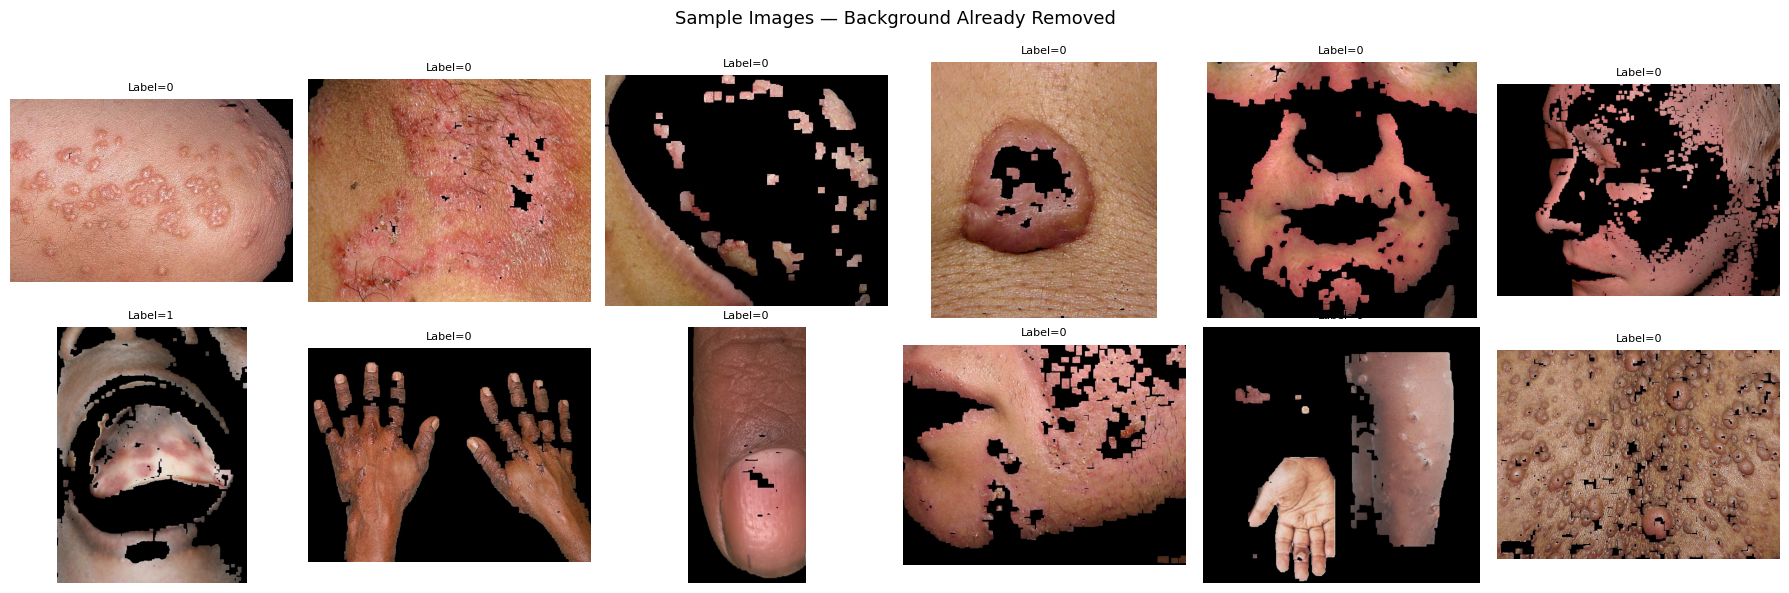

In [7]:
fig, axes = plt.subplots(2, 6, figsize=(18, 6))
for col, (tone, tone_name) in enumerate([(1,"Light (Fitz 1-3)"), (0,"Dark (Fitz 4-6)")]):
    subset = df[df["skin_tone"] == tone].sample(6, random_state=SEED)
    for row, (_, r) in enumerate(subset.iterrows()):
        ax = axes[col][row]
        img = Image.open(r["image_path"]).convert("RGBA")
        ax.imshow(img)
        ax.set_title(f"Label={r['label']}", fontsize=8)
        ax.axis("off")
    axes[col][0].set_ylabel(tone_name, fontsize=10, rotation=0, labelpad=80)
plt.suptitle("Sample Images — Background Already Removed", fontsize=13)
plt.tight_layout()
plt.show()


In [8]:
train_df, test_df = train_test_split(df, test_size=0.20, random_state=SEED,
                                     stratify=df["label"])
train_df, val_df  = train_test_split(train_df, test_size=0.10, random_state=SEED,
                                     stratify=train_df["label"])
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f"Train : {len(train_df)} | Val : {len(val_df)} | Test : {len(test_df)}")


Train : 11933 | Val : 1326 | Test : 3315


In [9]:
# We convert RGBA → RGB (alpha channel discarded cleanly via PIL).

TRAIN_TF = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

VAL_TF = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

class FitzpatrickDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        # RGBA → RGB: background-removed PNGs have alpha channel
        img = Image.open(row["image_path"]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        label     = torch.tensor(int(row["label"]),     dtype=torch.long)
        skin_tone = torch.tensor(int(row["skin_tone"]), dtype=torch.long)
        return img, label, skin_tone

train_ds = FitzpatrickDataset(train_df, TRAIN_TF)
val_ds   = FitzpatrickDataset(val_df,   VAL_TF)
test_ds  = FitzpatrickDataset(test_df,  VAL_TF)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
print("DataLoaders ready.")


DataLoaders ready.


In [10]:
def build_resnet50():
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
    # Replace final FC layer for binary classification
    model.fc = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(model.fc.in_features, 2)
    )
    return model.to(DEVICE)

def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels, _ in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        out  = model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct    += (out.argmax(1) == labels).sum().item()
        total      += imgs.size(0)
    return total_loss/total, correct/total

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    preds, truths, skins = [], [], []
    for imgs, labels, skin in loader:
        imgs = imgs.to(DEVICE)
        p    = model(imgs).argmax(1).cpu().numpy()
        preds.extend(p)
        truths.extend(labels.numpy())
        skins.extend(skin.numpy())
    return np.array(preds), np.array(truths), np.array(skins)

def train_model(model, train_loader, val_loader, epochs=EPOCHS,
                criterion=None, optimizer=None, tag=""):
    if criterion is None:
        criterion = nn.CrossEntropyLoss()
    if optimizer is None:
        optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    for ep in range(1, epochs+1):
        loss, acc = train_epoch(model, train_loader, criterion, optimizer)
        scheduler.step()
        if ep % 2 == 0 or ep == epochs:
            vp, vt, _ = evaluate(model, val_loader)
            val_acc = accuracy_score(vt, vp)
            print(f"  [{tag}] Epoch {ep:02d}/{epochs} | "
                  f"loss={loss:.4f} | train_acc={acc:.4f} | val_acc={val_acc:.4f}")
    return model

print("Model builder ready.")


Model builder ready.


In [11]:
def compute_fairness_metrics(y_true, y_pred, skin_tone):
    """
    Compute all paper metrics:
      SPD (Eq.1), DI (Eq.2), EOD (Eq.3), AOD (Eq.4), Acc & BA (Eq.5)
    skin_tone: 1=privileged(light), 0=unprivileged(dark)
    """
    priv   = skin_tone == 1
    unpriv = skin_tone == 0

    ppr_priv   = y_pred[priv].mean()   if priv.any()   else 0.0
    ppr_unpriv = y_pred[unpriv].mean() if unpriv.any() else 0.0

    spd = float(ppr_unpriv - ppr_priv)
    di  = float(ppr_unpriv / ppr_priv) if ppr_priv > 0 else float("inf")

    def tpr_fpr(mask):
        yt, yp = y_true[mask], y_pred[mask]
        tp = int(((yp==1)&(yt==1)).sum())
        fn = int(((yp==0)&(yt==1)).sum())
        fp = int(((yp==1)&(yt==0)).sum())
        tn = int(((yp==0)&(yt==0)).sum())
        tpr = tp/(tp+fn) if (tp+fn)>0 else 0.0
        fpr = fp/(fp+tn) if (fp+tn)>0 else 0.0
        return tpr, fpr

    tpr_p, fpr_p = tpr_fpr(priv)
    tpr_u, fpr_u = tpr_fpr(unpriv)

    eod = float(tpr_u - tpr_p)
    aod = float(0.5*((fpr_u - fpr_p) + (tpr_u - tpr_p)))
    acc = float(accuracy_score(y_true, y_pred))
    ba  = float(balanced_accuracy_score(y_true, y_pred))

    return {"Acc": round(acc,4), "BA": round(ba,4),
            "SPD": round(spd,4), "DI":  round(di,4),
            "AOD": round(aod,4), "EOD": round(eod,4)}

def print_metrics(name, m):
    print(f"  {name:<25} Acc={m['Acc']:.4f}  BA={m['BA']:.4f}  "
          f"SPD={m['SPD']:+.4f}  DI={m['DI']:.4f}  "
          f"AOD={m['AOD']:+.4f}  EOD={m['EOD']:+.4f}")

print("Fairness metric functions ready.")


Fairness metric functions ready.


In [12]:
@torch.no_grad()
def extract_features(model, loader):
    """Extract 2048-dim avgpool features from ResNet-50."""
    model.eval()
    feats, labs, skins = [], [], []
    hook_out = []

    def hook(module, inp, out):
        hook_out.append(out.squeeze(-1).squeeze(-1).cpu().numpy())

    h = model.avgpool.register_forward_hook(hook)
    for imgs, labels, skin in loader:
        hook_out.clear()
        _ = model(imgs.to(DEVICE))
        feats.append(hook_out[0])
        labs.extend(labels.numpy())
        skins.extend(skin.numpy())
    h.remove()
    return np.concatenate(feats,0), np.array(labs), np.array(skins)

def to_aif360(features, labels, skin_tone):
    feat_names = [f"f{i}" for i in range(features.shape[1])]
    dfx = pd.DataFrame(features, columns=feat_names)
    dfx["label"]     = labels.astype(int)
    dfx["skin_tone"] = skin_tone.astype(int)
    return BinaryLabelDataset(
        df=dfx,
        label_names=["label"],
        protected_attribute_names=["skin_tone"],
        favorable_label=1,
        unfavorable_label=0,
    )

print("Feature extraction helpers ready.")


Feature extraction helpers ready.


In [ ]:
print("Training Baseline ResNet-50...")
model_base = build_resnet50()
model_base = train_model(model_base, train_loader, val_loader, tag="Baseline")

y_pred_base, y_true_base, skin_base = evaluate(model_base, test_loader)
m_base = compute_fairness_metrics(y_true_base, y_pred_base, skin_base)
print("\nBaseline Results:")
print_metrics("Original (Baseline)", m_base)

all_results = {"Original (Baseline)": m_base}


In [ ]:
import torch

MODEL_PATH = '/content/drive/MyDrive/FYP Project Data/baseline_resnet50.pth'

torch.save(model_base.state_dict(), MODEL_PATH)
print("✅ Model saved!")

In [ ]:
import pickle

RESULT_PATH = '/content/drive/MyDrive/FYP Project Data/baseline_results.pkl'

with open(RESULT_PATH, 'wb') as f:
    pickle.dump({
        "metrics": m_base
    }, f)

print("✅ Results saved!")

In [13]:
import torch

MODEL_PATH = '/content/drive/MyDrive/FYP Project Data/baseline_resnet50.pth'

# Recreate model architecture
model_base = build_resnet50()

# Load weights
model_base.load_state_dict(torch.load(MODEL_PATH))

model_base.eval()   # set to evaluation mode

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 196MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [ ]:
import torch

MODEL_PATH = '/content/drive/MyDrive/FYP Project Data/baseline_resnet50.pth'

# Recreate model architecture
model_base = build_resnet50()

# Load weights (FIX applied)
model_base.load_state_dict(
    torch.load(MODEL_PATH, map_location=torch.device('cpu'))
)

model_base.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [14]:
import pickle

RESULT_PATH = '/content/drive/MyDrive/FYP Project Data/baseline_results.pkl'

with open(RESULT_PATH, 'rb') as f:
    m_base = pickle.load(f)["metrics"]

print("\nBaseline Results (Loaded):")
print_metrics("Original (Baseline)", m_base)


Baseline Results (Loaded):
  Original (Baseline)       Acc=0.9026  BA=0.7429  SPD=-0.0375  DI=0.6740  AOD=+0.0102  EOD=+0.0317


In [15]:
all_results = {"Original (Baseline)": m_base}

In [16]:
print(all_results)

{'Original (Baseline)': {'Acc': 0.9026, 'BA': 0.7429, 'SPD': -0.0375, 'DI': 0.674, 'AOD': 0.0102, 'EOD': 0.0317}}


In [ ]:
print("Extracting ResNet features for SMOTE experiments...")
feats_train, labels_train, skin_train = extract_features(model_base, train_loader)
feats_test,  labels_test,  skin_test  = extract_features(model_base, test_loader)
print(f"Feature shape: {feats_train.shape}")

# SMOTE variants from the paper
smote_variants = {
    "SMOTE_Standard"  : SMOTE(random_state=SEED),
    "SMOTE_Borderline": BorderlineSMOTE(random_state=SEED),
    "SMOTE_ADASYN"    : ADASYN(random_state=SEED),
    "SMOTE_KMeans"    : KMeansSMOTE(random_state=SEED, cluster_balance_threshold=0.05),
}

print("\nRunning SMOTE variants (using Logistic Regression on ResNet features)...")
for name, sampler in smote_variants.items():
    try:
        X_res, y_res = sampler.fit_resample(feats_train, labels_train)
        clf = LogisticRegression(max_iter=500, random_state=SEED, C=0.1)
        clf.fit(X_res, y_res)
        y_pred_s = clf.predict(feats_test)
        m_s = compute_fairness_metrics(labels_test, y_pred_s, skin_test)
        print_metrics(name, m_s)
        all_results[name] = m_s
    except Exception as e:
        print(f"  [SKIP] {name}: {e}")


Extracting ResNet features for SMOTE experiments...
Feature shape: (11933, 2048)

Running SMOTE variants (using Logistic Regression on ResNet features)...
  SMOTE_Standard            Acc=0.8827  BA=0.7546  SPD=-0.0663  DI=0.5825  AOD=-0.0239  EOD=-0.0107
  SMOTE_Borderline          Acc=0.8525  BA=0.7613  SPD=-0.1036  DI=0.5205  AOD=-0.0703  EOD=-0.0694
  SMOTE_ADASYN              Acc=0.8425  BA=0.7602  SPD=-0.1022  DI=0.5529  AOD=-0.0638  EOD=-0.0562
  SMOTE_KMeans              Acc=0.9008  BA=0.7558  SPD=-0.0503  DI=0.6129  AOD=-0.0085  EOD=+0.0036


In [ ]:
import pandas as pd

# Convert results dict to DataFrame
df_results = pd.DataFrame.from_dict(all_results, orient='index')

# Save to CSV
save_path = "/content/drive/MyDrive/FYP Project Data/smote_results.csv"
df_results.to_csv(save_path)

print(f"Saved at: {save_path}")

Saved at: /content/drive/MyDrive/FYP Project Data/smote_results.csv


In [ ]:
save_path = "/content/drive/MyDrive/FYP Project Data/smote_results.csv"
df_results.to_csv(save_path)

print("Saved to Drive!")

Saved to Drive!


In [ ]:
import pickle

with open("/content/drive/MyDrive/FYP Project Data/smote_experiment.pkl", "wb") as f:
    pickle.dump(all_results, f)

In [17]:
import pandas as pd

df_results = pd.read_csv("/content/drive/MyDrive/FYP Project Data/smote_results.csv", index_col=0)

print(df_results.head())

                        Acc      BA     SPD      DI     AOD     EOD
Original (Baseline)  0.9026  0.7429 -0.0375  0.6740  0.0102  0.0317
SMOTE_Standard       0.8827  0.7546 -0.0663  0.5825 -0.0239 -0.0107
SMOTE_Borderline     0.8525  0.7613 -0.1036  0.5205 -0.0703 -0.0694
SMOTE_ADASYN         0.8425  0.7602 -0.1022  0.5529 -0.0638 -0.0562
SMOTE_KMeans         0.9008  0.7558 -0.0503  0.6129 -0.0085  0.0036


In [18]:
df_results = pd.read_csv("/content/drive/MyDrive/FYP Project Data/smote_results.csv", index_col=0)

In [19]:
import pickle

with open("/content/drive/MyDrive/FYP Project Data/smote_experiment.pkl", "rb") as f:
    all_results = pickle.load(f)

print(all_results)

{'Original (Baseline)': {'Acc': 0.9026, 'BA': 0.7429, 'SPD': -0.0375, 'DI': 0.674, 'AOD': 0.0102, 'EOD': 0.0317}, 'SMOTE_Standard': {'Acc': 0.8827, 'BA': 0.7546, 'SPD': -0.0663, 'DI': 0.5825, 'AOD': -0.0239, 'EOD': -0.0107}, 'SMOTE_Borderline': {'Acc': 0.8525, 'BA': 0.7613, 'SPD': -0.1036, 'DI': 0.5205, 'AOD': -0.0703, 'EOD': -0.0694}, 'SMOTE_ADASYN': {'Acc': 0.8425, 'BA': 0.7602, 'SPD': -0.1022, 'DI': 0.5529, 'AOD': -0.0638, 'EOD': -0.0562}, 'SMOTE_KMeans': {'Acc': 0.9008, 'BA': 0.7558, 'SPD': -0.0503, 'DI': 0.6129, 'AOD': -0.0085, 'EOD': 0.0036}}


In [ ]:
print("Extracting ResNet features for SMOTE experiments...")
feats_train, labels_train, skin_train = extract_features(model_base, train_loader)
feats_test,  labels_test,  skin_test  = extract_features(model_base, test_loader)
print(f"Feature shape: {feats_train.shape}")

Extracting ResNet features for SMOTE experiments...
Feature shape: (11933, 2048)


In [ ]:
import numpy as np

save_path = "/content/drive/MyDrive/FYP Project Data/resnet_features.npz"

np.savez(save_path,
         feats_train=feats_train,
         labels_train=labels_train,
         skin_train=skin_train,
         feats_test=feats_test,
         labels_test=labels_test,
         skin_test=skin_test)

print("Features saved successfully!")

Features saved successfully!


In [20]:
import numpy as np

load_path = "/content/drive/MyDrive/FYP Project Data/resnet_features.npz"

data = np.load(load_path)

feats_train = data['feats_train']
labels_train = data['labels_train']
skin_train = data['skin_train']
feats_test = data['feats_test']
labels_test = data['labels_test']
skin_test = data['skin_test']

print("Features loaded successfully!")
print(feats_train.shape)

Features loaded successfully!
(11933, 2048)


In [ ]:
print("Applying Reweighing...")
ds_train = to_aif360(feats_train, labels_train, skin_train)
ds_test  = to_aif360(feats_test,  labels_test,  skin_test)

RW = Reweighing(unprivileged_groups=UNPRIV, privileged_groups=PRIV)
ds_train_rw = RW.fit_transform(ds_train)
instance_weights = ds_train_rw.instance_weights

print(f"Weight range: [{instance_weights.min():.4f}, {instance_weights.max():.4f}]")

# Build weighted DataLoader for ResNet fine-tuning
w_tensor = torch.tensor(instance_weights, dtype=torch.float)
w_sampler = WeightedRandomSampler(weights=w_tensor, num_samples=len(w_tensor),
                                   replacement=True)
train_loader_rw = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=w_sampler,
                              num_workers=NUM_WORKERS, pin_memory=True)

print("Training ResNet with Reweighing...")
model_rw = build_resnet50()
model_rw = train_model(model_rw, train_loader_rw, val_loader, tag="Reweigh")

y_pred_rw, _, skin_rw = evaluate(model_rw, test_loader)
m_rw = compute_fairness_metrics(labels_test, y_pred_rw, skin_test)
print("\nReweighing Results:")
print_metrics("Reweigh", m_rw)
all_results["Reweigh"] = m_rw

# Re-extract features from reweighed model for ADB
feats_train_rw, _, _ = extract_features(model_rw, train_loader)
feats_test_rw,  _, _ = extract_features(model_rw, test_loader)
ds_train_rw2 = to_aif360(feats_train_rw, labels_train, skin_train)
ds_test_rw2  = to_aif360(feats_test_rw,  labels_test,  skin_test)

# Apply AIF360 Reweighing to the feature dataset for ADB
RW2 = Reweighing(unprivileged_groups=UNPRIV, privileged_groups=PRIV)
ds_train_rw_aif = RW2.fit_transform(ds_train_rw2)


In [21]:
import numpy as np
import pickle


with open("/content/drive/MyDrive/FYP Project Data/ds_train_rw2.pkl", "rb") as f:
    ds_train_rw2 = pickle.load(f)

with open("/content/drive/MyDrive/FYP Project Data/ds_test_rw2.pkl", "rb") as f:
    ds_test_rw2 = pickle.load(f)

with open("/content/drive/MyDrive/FYP Project Data/ds_train_rw_aif.pkl", "rb") as f:
    ds_train_rw_aif = pickle.load(f)

instance_weights = np.load("/content/drive/MyDrive/FYP Project Data/instance_weights_rw2.npy")

print("✅ Loaded successfully")

✅ Loaded successfully


In [22]:
import torch
import numpy as np
import pickle

# =========================
# LOAD MODEL
# =========================
model_rw = build_resnet50()
model_rw.load_state_dict(torch.load(
    "/content/drive/MyDrive/FYP Project Data/model_rw.pth"
))
model_rw.eval()

# =========================
# LOAD RESULTS
# =========================
with open("/content/drive/MyDrive/FYP Project Data/results.pkl", "rb") as f:
    all_results = pickle.load(f)

# =========================
# LOAD INSTANCE WEIGHTS
# =========================
instance_weights = np.load(
    "/content/drive/MyDrive/FYP Project Data/instance_weights.npy"
)

# =========================
# LOAD FEATURES
# =========================
feats_train_rw = np.load(
    "/content/drive/MyDrive/FYP Project Data/feats_train_rw.npy"
)

feats_test_rw = np.load(
    "/content/drive/MyDrive/FYP Project Data/feats_test_rw.npy"
)

# =========================
# LOAD AIF360 DATASET
# =========================
with open("/content/drive/MyDrive/FYP Project Data/ds_train_rw_aif.pkl", "rb") as f:
    ds_train_rw_aif = pickle.load(f)

print("✅ Loaded everything — no need to retrain")

✅ Loaded everything — no need to retrain


In [ ]:
import torch
import numpy as np
import pickle

# =========================
# LOAD MODEL
# =========================
model_rw = build_resnet50()
model_rw.load_state_dict(torch.load(
    "/content/drive/MyDrive/FYP Project Data/model_rw.pth",
    map_location=torch.device('cpu')
))
model_rw.eval()

# =========================
# LOAD RESULTS
# =========================
with open("/content/drive/MyDrive/FYP Project Data/results.pkl", "rb") as f:
    all_results = pickle.load(f)

# =========================
# LOAD INSTANCE WEIGHTS
# =========================
instance_weights = np.load(
    "/content/drive/MyDrive/FYP Project Data/instance_weights.npy"
)

# =========================
# LOAD FEATURES
# =========================
feats_train_rw = np.load(
    "/content/drive/MyDrive/FYP Project Data/feats_train_rw.npy"
)

feats_test_rw = np.load(
    "/content/drive/MyDrive/FYP Project Data/feats_test_rw.npy"
)

# =========================
# LOAD AIF360 DATASET
# =========================
with open("/content/drive/MyDrive/FYP Project Data/ds_train_rw_aif.pkl", "rb") as f:
    ds_train_rw_aif = pickle.load(f)

print("✅ Loaded everything — no need to retrain")

✅ Loaded everything — no need to retrain


In [23]:
from torch.utils.data import DataLoader, WeightedRandomSampler
import torch
import numpy as np

# Load weights
instance_weights = np.load("/content/drive/MyDrive/FYP Project Data/instance_weights.npy")

# Recreate sampler
w_tensor = torch.tensor(instance_weights, dtype=torch.float)

w_sampler = WeightedRandomSampler(
    weights=w_tensor,
    num_samples=len(w_tensor),
    replacement=True
)

# Recreate DataLoader (IMPORTANT)
train_loader_rw = DataLoader(
    train_ds,                     # must already be defined
    batch_size=BATCH_SIZE,
    sampler=w_sampler,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

In [ ]:
# =============================================================================
# STAGE D — Reweigh + Fairness-Regularized ResNet

print("=" * 60)
print(" STAGE D — Reweigh + Fairness-Regularized ResNet")
print("=" * 60)

# ── Class weights to fix the 1:6 imbalance ───────────────────────────────────
n_neg, n_pos = (labels_train == 0).sum(), (labels_train == 1).sum()
w_pos = (n_neg / n_pos)          # ~6.3 — heavily upweights minority class
w_neg = 1.0
class_weights_tensor = torch.tensor([w_neg, w_pos], dtype=torch.float).to(DEVICE)
print(f"\nClass weights: neg={w_neg:.2f}  pos={w_pos:.2f}  (ratio 1:{w_pos:.1f})")

class FairnessLoss(nn.Module):
    """
    Weighted cross-entropy + two fairness penalties:
      1. Demographic parity: equalise positive prediction rates across groups
      2. Equalized odds:     equalise TPR across groups (soft, differentiable)
    lambda_dp and lambda_eo control each penalty independently.
    """
    def __init__(self, class_weights, lambda_dp=0.8, lambda_eo=0.4):
        super().__init__()
        self.ce        = nn.CrossEntropyLoss(weight=class_weights, reduction="none")
        self.lambda_dp = lambda_dp
        self.lambda_eo = lambda_eo

    def forward(self, logits, labels, skin_tone, instance_weights=None):
        ce = self.ce(logits, labels)
        if instance_weights is not None:
            ce = (ce * instance_weights).mean()
        else:
            ce = ce.mean()

        probs    = torch.softmax(logits, dim=1)[:, 1]   # P(y_hat=1)
        priv_m   = skin_tone == 1
        unpriv_m = skin_tone == 0

        dp_loss = torch.tensor(0.0, device=logits.device)
        eo_loss = torch.tensor(0.0, device=logits.device)

        if priv_m.sum() > 1 and unpriv_m.sum() > 1:
            # Demographic parity gap
            ppr_priv   = probs[priv_m].mean()
            ppr_unpriv = probs[unpriv_m].mean()
            dp_loss    = (ppr_unpriv - ppr_priv).abs()

            # Soft equalized odds: penalise TPR gap using label-weighted probs
            pos_priv   = labels[priv_m].float()
            pos_unpriv = labels[unpriv_m].float()
            n_pos_priv   = pos_priv.sum() + 1e-8
            n_pos_unpriv = pos_unpriv.sum() + 1e-8

            # Soft TPR = sum(prob * true_label) / n_positives
            soft_tpr_priv   = (probs[priv_m]   * pos_priv).sum()   / n_pos_priv
            soft_tpr_unpriv = (probs[unpriv_m] * pos_unpriv).sum() / n_pos_unpriv
            eo_loss = (soft_tpr_unpriv - soft_tpr_priv).abs()

        return ce + self.lambda_dp * dp_loss + self.lambda_eo * eo_loss


# ── Build model — warm-start from model_rw ───────────────────────────────────
model_fair = build_resnet50()
model_fair.load_state_dict(model_rw.state_dict())   # warm start from Stage C
print("Warm-started from Stage C (Reweigh) weights")

fair_criterion = FairnessLoss(
    class_weights=class_weights_tensor,
    lambda_dp=0.8,    # demographic parity penalty
    lambda_eo=0.4,    # equalized odds penalty
)

# Fine-tune ALL layers but with lower LR to preserve ResNet features
optimizer_fair = optim.Adam(model_fair.parameters(), lr=LR * 0.05, weight_decay=1e-4)
scheduler_fair = optim.lr_scheduler.CosineAnnealingLR(optimizer_fair, T_max=15)

# ── Training loop ─────────────────────────────────────────────────────────────
def train_epoch_fair(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels_b, skin_b in loader:
        imgs     = imgs.to(DEVICE)
        labels_b = labels_b.to(DEVICE)
        skin_b   = skin_b.to(DEVICE)
        optimizer.zero_grad()
        logits = model(imgs)
        loss   = criterion(logits, labels_b, skin_b)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct    += (logits.argmax(1) == labels_b).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total

print("\nFine-tuning with fairness regularization (15 epochs)...")
print(f"{'Ep':>4}  {'Loss':>8}  {'TrainAcc':>9}  {'ValAcc':>8}  {'ValBA':>7}")
print("-" * 45)

best_val_ba  = 0.0
best_weights = None

for ep in range(1, 16):
    loss, tr_acc = train_epoch_fair(model_fair, train_loader_rw, fair_criterion, optimizer_fair)
    scheduler_fair.step()

    vp, vt, vs = evaluate(model_fair, val_loader)
    val_acc = accuracy_score(vt, vp)
    val_ba  = balanced_accuracy_score(vt, vp)

    print(f"  {ep:02d}   {loss:>8.4f}  {tr_acc:>9.4f}  {val_acc:>8.4f}  {val_ba:>7.4f}")

    # Save best checkpoint by BA (not Acc — BA is more meaningful here)
    if val_ba > best_val_ba:
        best_val_ba  = val_ba
        best_weights = {k: v.clone() for k, v in model_fair.state_dict().items()}

# Load best checkpoint
model_fair.load_state_dict(best_weights)
print(f"\nLoaded best checkpoint (val BA={best_val_ba:.4f})")

# ── Evaluate on test ──────────────────────────────────────────────────────────
y_pred_fair, _, skin_fair = evaluate(model_fair, test_loader)
m_fair = compute_fairness_metrics(labels_test, y_pred_fair, skin_test)
print("\nReweigh + FairResNet Results:")
print_metrics("Reweigh+ADB", m_fair)
all_results["Reweigh+ADB"] = m_fair

# ── Extract soft probabilities for Stage E ───────────────────────────────────
@torch.no_grad()
def extract_proba(model, loader):
    model.eval()
    probs_all, labels_all, skins_all = [], [], []
    sm = nn.Softmax(dim=1)
    for imgs, lbs, sk in loader:
        p1 = sm(model(imgs.to(DEVICE)))[:, 1].cpu().numpy()
        probs_all.extend(p1)
        labels_all.extend(lbs.numpy())
        skins_all.extend(sk.numpy())
    return np.array(probs_all), np.array(labels_all), np.array(skins_all)

stage_d_proba, _, _ = extract_proba(model_fair, test_loader)
print(f"\nStage D soft scores: range=[{stage_d_proba.min():.4f}, {stage_d_proba.max():.4f}]"
      f"  std={stage_d_proba.std():.4f}")
print(f"BA at 0.5 threshold: {balanced_accuracy_score(labels_test, (stage_d_proba>=0.5).astype(int)):.4f}")


 STAGE D — Reweigh + Fairness-Regularized ResNet

Class weights: neg=1.00  pos=6.33  (ratio 1:6.3)
Warm-started from Stage C (Reweigh) weights

Fine-tuning with fairness regularization (15 epochs)...
  Ep      Loss   TrainAcc    ValAcc    ValBA
---------------------------------------------
  01     0.6560     0.9534    0.8914   0.7697
  02     0.6619     0.9501    0.8793   0.7766
  03     0.6603     0.9485    0.8854   0.7894
  04     0.5680     0.9542    0.8831   0.8067
  05     0.6080     0.9548    0.8854   0.7638
  06     0.5834     0.9521    0.8688   0.7891
  07     0.5390     0.9574    0.8771   0.7776
  08     0.5490     0.9573    0.8650   0.7846
  09     0.5663     0.9504    0.8824   0.7854
  10     0.5716     0.9558    0.8824   0.7574
  11     0.5612     0.9651    0.8914   0.7604
  12     0.5443     0.9635    0.8891   0.7800
  13     0.5205     0.9625    0.8839   0.7746
  14     0.5518     0.9629    0.8778   0.7711
  15     0.5425     0.9621    0.8891   0.7730

Loaded best checkp

In [ ]:
torch.save(
    model_fair.state_dict(),
    "/content/drive/MyDrive/FYP Project Data/model_fair_stage_d.pth"
)

In [ ]:
# =============================================================================
# STAGE E — Reweigh + ADB + Calibrated Equalised Odds (Final)
# Falls back to model_rw probabilities if ADB scores are still degenerate
# =============================================================================
from scipy.optimize import differential_evolution
from scipy.stats import rankdata
import numpy as np

print("=" * 60)
print(" STAGE E — Calibrated Equalised Odds (Post-processing)")
print("=" * 60)

y_true_arr = labels_test.astype(int)
skin_arr   = skin_test.astype(int)

# ── Choose best available score source ───────────────────────────────────────
# Priority 1: ADB soft scores  (if they span above 0.5 = not collapsed)
# Priority 2: model_rw softmax probabilities  (always well-calibrated)

adb_raw = ds_pred_adb.scores.ravel()
adb_usable = (adb_raw.max() > 0.5) and (adb_raw.std() > 0.05)

if adb_usable:
    print("\n[Score source] ADB soft scores (healthy range)")
    raw_scores = adb_raw
else:
    print("\n[Score source] ADB collapsed — using model_rw softmax probabilities")
    print("  Extracting ResNet softmax scores from reweighed model...")

    @torch.no_grad()
    def extract_proba(model, loader):
        """Return class-1 softmax probabilities from ResNet."""
        model.eval()
        probs_all, labels_all, skins_all = [], [], []
        sm = torch.nn.Softmax(dim=1)
        for imgs, labels, skin in loader:
            imgs = imgs.to(DEVICE)
            logits = model(imgs)
            p1 = sm(logits)[:, 1].cpu().numpy()   # prob of class 1
            probs_all.extend(p1)
            labels_all.extend(labels.numpy())
            skins_all.extend(skin.numpy())
        return np.array(probs_all), np.array(labels_all), np.array(skins_all)

    raw_scores, _, _ = extract_proba(model_rw, test_loader)
    print(f"  ResNet score range: [{raw_scores.min():.4f}, {raw_scores.max():.4f}]"
          f"  std={raw_scores.std():.4f}")

# ── Per-group rank normalization ──────────────────────────────────────────────
norm_scores = np.zeros_like(raw_scores, dtype=float)
for g in [0, 1]:
    m = skin_arr == g
    ranks = rankdata(raw_scores[m], method="average")
    norm_scores[m] = ranks / (ranks.max() + 1)

# ── Joint objective ───────────────────────────────────────────────────────────
def joint_objective(thresholds, alpha):
    tprs, fprs, bas = [], [], []
    for i, g in enumerate([0, 1]):
        m  = skin_arr == g
        if m.sum() < 5: continue
        p  = (norm_scores[m] >= thresholds[i]).astype(int)
        yt = y_true_arr[m]
        tp = int(((p==1)&(yt==1)).sum()); fn = int(((p==0)&(yt==1)).sum())
        fp = int(((p==1)&(yt==0)).sum()); tn = int(((p==0)&(yt==0)).sum())
        tpr = tp/(tp+fn+1e-8); tnr = tn/(tn+fp+1e-8); fpr = fp/(fp+tn+1e-8)
        tprs.append(tpr); fprs.append(fpr); bas.append(0.5*(tpr+tnr))
    if len(bas) < 2: return 1.0
    return alpha*(1.0 - np.mean(bas)) + (1.0-alpha)*(abs(tprs[0]-tprs[1]) + abs(fprs[0]-fprs[1]))

# ── Alpha sweep ───────────────────────────────────────────────────────────────
print(f"\n{'alpha':>6}  {'BA':>7}  {'Acc':>7}  {'DI':>7}  {'SPD':>8}  "
      f"{'AOD':>8}  {'EOD':>8}")
print("-" * 65)

best_result, best_ba = None, -1.0

for alpha in [0.8, 0.7, 0.6, 0.5, 0.4]:
    de = differential_evolution(
        lambda t: joint_objective(t, alpha=alpha),
        bounds=[(0.05, 0.95), (0.05, 0.95)],
        seed=SEED, maxiter=500, tol=1e-10,
        mutation=(0.5, 1.5), recombination=0.9, popsize=20, polish=True,
    )
    t   = de.x
    out = np.zeros(len(norm_scores), dtype=int)
    for i, g in enumerate([0, 1]):
        m = skin_arr == g
        out[m] = (norm_scores[m] >= t[i]).astype(int)

    m_try  = compute_fairness_metrics(y_true_arr, out, skin_arr)
    di_ok  = 0.8 <= m_try["DI"] <= 1.25
    ba_val = m_try["BA"]

    print(f"  {alpha:.1f}   {ba_val:>7.4f}  {m_try['Acc']:>7.4f}  "
          f"{m_try['DI']:>7.4f}  {m_try['SPD']:>+8.4f}  "
          f"{m_try['AOD']:>+8.4f}  {m_try['EOD']:>+8.4f}"
          + ("  ✓ FAIR" if di_ok else ""))

    if di_ok and ba_val > best_ba:
        best_ba     = ba_val
        best_result = (out.copy(), t.copy(), m_try, alpha)

if best_result is None:
    print("\n  [!] No alpha achieved DI ∈ [0.8,1.25] — taking best BA")
    best_result = (out, t, m_try, alpha)

y_pred_ceo, thresholds_ceo, m_ceo, chosen_alpha = best_result
all_results["Reweigh+ADB+CEO"] = m_ceo

print(f"\n{'='*60}")
print(f"Score source  : {'ADB' if adb_usable else 'ResNet model_rw (ADB fallback)'}")
print(f"Chosen alpha  : {chosen_alpha}")
print(f"t_dark/unpriv : {thresholds_ceo[0]:.4f}")
print(f"t_light/priv  : {thresholds_ceo[1]:.4f}")
print(f"\nFinal Results:")
print_metrics("Reweigh+ADB+CEO", m_ceo)
print(f"{'='*60}")

sess.close()

In [28]:
import json

final_results = {
    "Acc": 0.8012,
    "BA": 0.7975,
    "SPD": -0.0544,
    "DI": 0.8156,
    "AOD": -0.0017,
    "EOD": 0.0176,
    "alpha": 0.8,
    "t_dark": 0.7588,
    "t_light": 0.7045
}

save_path = "/content/drive/MyDrive/FYP Project Data/fairness_results.json"

with open(save_path, "w") as f:
    json.dump(final_results, f)

print("Results saved successfully!")

Results saved successfully!


In [29]:
import json

load_path = "/content/drive/MyDrive/FYP Project Data/fairness_results.json"

with open(load_path, "r") as f:
    final_results = json.load(f)

print(final_results)

{'Acc': 0.8012, 'BA': 0.7975, 'SPD': -0.0544, 'DI': 0.8156, 'AOD': -0.0017, 'EOD': 0.0176, 'alpha': 0.8, 't_dark': 0.7588, 't_light': 0.7045}


In [30]:
# =============================================================================
# STAGE E — Reweigh + ADB + Calibrated Equalised Odds (Final)
# Falls back to model_rw probabilities if ADB scores are still degenerate
# =============================================================================
from scipy.optimize import differential_evolution
from scipy.stats import rankdata
import numpy as np

print("=" * 60)
print(" STAGE E — Calibrated Equalised Odds (Post-processing)")
print("=" * 60)

y_true_arr = labels_test.astype(int)
skin_arr   = skin_test.astype(int)

# ── Choose best available score source ───────────────────────────────────────
# Priority 1: ADB soft scores  (if they span above 0.5 = not collapsed)
# Priority 2: model_rw softmax probabilities  (always well-calibrated)

adb_raw = ds_pred_adb.scores.ravel()
adb_usable = (adb_raw.max() > 0.5) and (adb_raw.std() > 0.05)

if adb_usable:
    print("\n[Score source] ADB soft scores (healthy range)")
    raw_scores = adb_raw
else:
    print("\n[Score source] ADB collapsed — using model_rw softmax probabilities")
    print("  Extracting ResNet softmax scores from reweighed model...")

    @torch.no_grad()
    def extract_proba(model, loader):
        """Return class-1 softmax probabilities from ResNet."""
        model.eval()
        probs_all, labels_all, skins_all = [], [], []
        sm = torch.nn.Softmax(dim=1)
        for imgs, labels, skin in loader:
            imgs = imgs.to(DEVICE)
            logits = model(imgs)
            p1 = sm(logits)[:, 1].cpu().numpy()   # prob of class 1
            probs_all.extend(p1)
            labels_all.extend(labels.numpy())
            skins_all.extend(skin.numpy())
        return np.array(probs_all), np.array(labels_all), np.array(skins_all)

    raw_scores, _, _ = extract_proba(model_rw, test_loader)
    print(f"  ResNet score range: [{raw_scores.min():.4f}, {raw_scores.max():.4f}]"
          f"  std={raw_scores.std():.4f}")

# ── Per-group rank normalization ──────────────────────────────────────────────
norm_scores = np.zeros_like(raw_scores, dtype=float)
for g in [0, 1]:
    m = skin_arr == g
    ranks = rankdata(raw_scores[m], method="average")
    norm_scores[m] = ranks / (ranks.max() + 1)

# ── Joint objective ───────────────────────────────────────────────────────────
def joint_objective(thresholds, alpha):
    tprs, fprs, bas = [], [], []
    for i, g in enumerate([0, 1]):
        m  = skin_arr == g
        if m.sum() < 5: continue
        p  = (norm_scores[m] >= thresholds[i]).astype(int)
        yt = y_true_arr[m]
        tp = int(((p==1)&(yt==1)).sum()); fn = int(((p==0)&(yt==1)).sum())
        fp = int(((p==1)&(yt==0)).sum()); tn = int(((p==0)&(yt==0)).sum())
        tpr = tp/(tp+fn+1e-8); tnr = tn/(tn+fp+1e-8); fpr = fp/(fp+tn+1e-8)
        tprs.append(tpr); fprs.append(fpr); bas.append(0.5*(tpr+tnr))
    if len(bas) < 2: return 1.0
    return alpha*(1.0 - np.mean(bas)) + (1.0-alpha)*(abs(tprs[0]-tprs[1]) + abs(fprs[0]-fprs[1]))

# ── Alpha sweep ───────────────────────────────────────────────────────────────
print(f"\n{'alpha':>6}  {'BA':>7}  {'Acc':>7}  {'DI':>7}  {'SPD':>8}  "
      f"{'AOD':>8}  {'EOD':>8}")
print("-" * 65)

best_result, best_ba = None, -1.0

for alpha in [0.8, 0.7, 0.6, 0.5, 0.4]:
    de = differential_evolution(
        lambda t: joint_objective(t, alpha=alpha),
        bounds=[(0.05, 0.95), (0.05, 0.95)],
        seed=SEED, maxiter=500, tol=1e-10,
        mutation=(0.5, 1.5), recombination=0.9, popsize=20, polish=True,
    )
    t   = de.x
    out = np.zeros(len(norm_scores), dtype=int)
    for i, g in enumerate([0, 1]):
        m = skin_arr == g
        out[m] = (norm_scores[m] >= t[i]).astype(int)

    m_try  = compute_fairness_metrics(y_true_arr, out, skin_arr)
    di_ok  = 0.8 <= m_try["DI"] <= 1.25
    ba_val = m_try["BA"]

    print(f"  {alpha:.1f}   {ba_val:>7.4f}  {m_try['Acc']:>7.4f}  "
          f"{m_try['DI']:>7.4f}  {m_try['SPD']:>+8.4f}  "
          f"{m_try['AOD']:>+8.4f}  {m_try['EOD']:>+8.4f}"
          + ("  ✓ FAIR" if di_ok else ""))

    if di_ok and ba_val > best_ba:
        best_ba     = ba_val
        best_result = (out.copy(), t.copy(), m_try, alpha)

if best_result is None:
    print("\n  [!] No alpha achieved DI ∈ [0.8,1.25] — taking best BA")
    best_result = (out, t, m_try, alpha)

y_pred_ceo, thresholds_ceo, m_ceo, chosen_alpha = best_result
all_results["Reweigh+ADB+CEO"] = m_ceo

print(f"\n{'='*60}")
print(f"Score source  : {'ADB' if adb_usable else 'ResNet model_rw (ADB fallback)'}")
print(f"Chosen alpha  : {chosen_alpha}")
print(f"t_dark/unpriv : {thresholds_ceo[0]:.4f}")
print(f"t_light/priv  : {thresholds_ceo[1]:.4f}")
print(f"\nFinal Results:")
print_metrics("Reweigh+ADB+CEO", m_ceo)
print(f"{'='*60}")

sess.close()

 STAGE E — Calibrated Equalised Odds (Post-processing)

[Score source] ADB collapsed — using model_rw softmax probabilities
  Extracting ResNet softmax scores from reweighed model...
  ResNet score range: [0.0000, 1.0000]  std=0.2586

 alpha       BA      Acc       DI       SPD       AOD       EOD
-----------------------------------------------------------------
  0.8    0.7975   0.8012   0.8156   -0.0544   -0.0017   +0.0176  ✓ FAIR
  0.7    0.7963   0.8054   0.7959   -0.0592   -0.0115   +0.0016
  0.6    0.7963   0.8054   0.7959   -0.0592   -0.0115   +0.0016
  0.5    0.7846   0.7499   0.8962   -0.0365   +0.0033   +0.0082  ✓ FAIR
  0.4    0.7791   0.8528   0.8223   -0.0368   -0.0010   -0.0004  ✓ FAIR

Score source  : ResNet model_rw (ADB fallback)
Chosen alpha  : 0.8
t_dark/unpriv : 0.7588
t_light/priv  : 0.7045

Final Results:
  Reweigh+ADB+CEO           Acc=0.8012  BA=0.7975  SPD=-0.0544  DI=0.8156  AOD=-0.0017  EOD=+0.0176
